# Logistic Regression

## Why is it called "Regression" and not Classification?

Logistic Regression is used for classification tasks, but it is called *regression* because:

- It models the **probability** of a class (a continuous value between 0 and 1)
- It first computes a linear combination:
  
  z = wᵀx + b

- Then applies the **sigmoid (logistic) function**:

  σ(z) = 1 / (1 + e⁻ᶻ)

- This outputs a probability, which is then converted into a class label using a threshold (e.g., 0.5)

👉 So technically, it performs regression on probabilities, and classification is a post-processing step.

---

## What Assumptions Does Logistic Regression Make?

### 1. Linearity of decission boundery

- it assumes that the data is linearly seperable
---

### 2. Not Strictly Linear Separability

- Logistic Regression does **NOT require** perfectly linearly separable data
- However:
  - It performs best when data is approximately linearly separable
  - If data is perfectly separable, model parameters can become very large (unstable)


In [1]:
import math
import warnings
import numpy as np 
from matplotlib import cm 
import ipywidgets as widgets
import matplotlib.pyplot as plt 
warnings.filterwarnings('ignore') 
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, interactive, fixed, interact_manual

# Segmoid Function 
## σ(z) = 1 / (1 + e⁻ᶻ)

In [2]:
def sigmoid(x, derivative = False):
    prob = 1/ (1+ np.exp(-x)) 

    if derivative:
        d_segmoid = prob * (1 - prob) 
        return d_segmoid
    return prob

In [3]:
# Generate Data points 
x = np.arange(-5,5,0.1) 
y = sigmoid(x) 
y_deriv = sigmoid(x, derivative=True) 
x[::20],y[::20],y_deriv[::20]

(array([-5., -3., -1.,  1.,  3.]),
 array([0.00669285, 0.04742587, 0.26894142, 0.73105858, 0.95257413]),
 array([0.00664806, 0.04517666, 0.19661193, 0.19661193, 0.04517666]))

Max value of Deravative of sigmoid is: 0.25 at x = 0


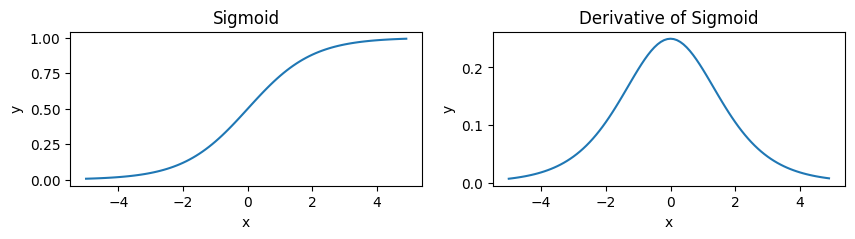

In [4]:
# Plot the segmoid 
_, ax = plt.subplots(1,2, figsize = (10,2))
ax1 = ax[0] 
ax1.plot(x,y) 
ax1.set_title('Sigmoid')
ax1.set_xlabel('x') 
ax1.set_ylabel('y') 

# plot the derivative of the sigmoid 
ax2 = ax[1] 
ax2.plot(x,y_deriv) 
ax2.set_title('Derivative of Sigmoid')
ax2.set_xlabel('x') 
ax2.set_ylabel('y')

print(f"Max value of Deravative of sigmoid is: 0.25 at x = 0")

In [5]:
# model 
def h_theta(x, w, b=0):
    z = (x @ W) + b 
    return z 

In [7]:
x = np.array([4,8]) 
w = np.array([1,2]) 
print('theta transpose x = z', x @ w) 
print('sigmoid of theta teanspose x: ', sigmoid(x @ w))
print('rounding for classification: ', np.round(sigmoid(x @ w))) 

theta transpose x = z 20
sigmoid of theta teanspose x:  0.9999999979388463
rounding for classification:  1.0


# Loss function for logistic Regression
### Binary Cross-Entropy (BCE) Loss

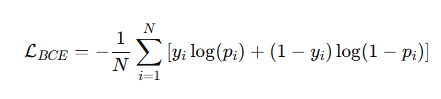

In [8]:
def cross_entropy_loss(y, h):
    loss = -np.mean(y * np.log(h) + (1-y) * np.log(1-h)) 
    return loss 

y = np.array([1,1,1,0,0,0]) # <-- true label
bad_h = np.array([0.01, 0.01, 0.01, 0.99, 0.99, 0.99]) # <--- very bad predictor 
good_h = bad_h[:: -1]  # <--- good predictor 

print('bad h should give high loss: ', cross_entropy_loss(y, bad_h)) 
print('good h should give low loss: ', cross_entropy_loss(y, good_h)) 

bad h should give high loss:  4.605170185988091
good h should give low loss:  0.01005033585350145


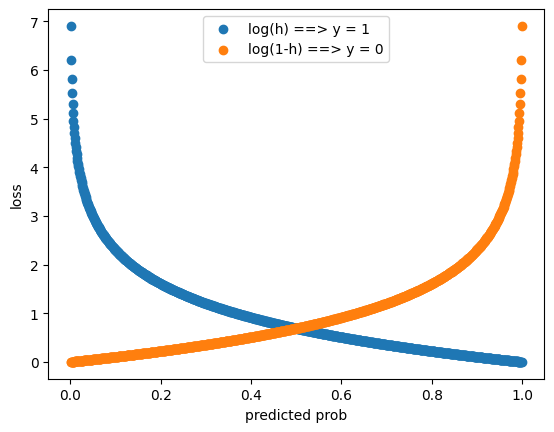

In [9]:
h = np.linspace(0.001, 0.999, 1000) 
plt.scatter(h, -np.log(h), label = 'log(h) ==> y = 1') 
plt.scatter(h, -np.log(1-h) , label = 'log(1-h) ==> y = 0')
plt.ylabel('loss') 
plt.xlabel('predicted prob') 
plt.legend(); 
plt.show()

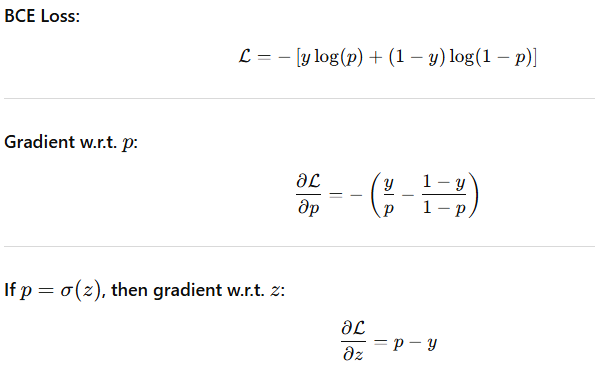

In [29]:
import numpy as np 
import matplotlib.pyplot as plt 
import os 
from matplotlib.animation import FuncAnimation 

class LogisticRegression :
    def __init__ (self, learning_rate= 0.01, max_iter = 1000, batch_size = 32) :
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.weights = None # to be initialized in fit 
        self.losses = [] # to keep track of loss over iterations

    def _sigmoid(self, z) :
        # Sigmoid activation function 
        return 1/ (1 + np.exp(-z)) 

    def _h_theta(self, X) : 
        # Hypothesis function: Sigmoid(X * weights) 
        return self._sigmoid(np.dot(X, self.weights)) 

    def _cross_entropy_loss(self, h, y):
        # Cross-entropy loss function 
        h = np.clip(h, 1e-15, 1 - 1e-15)
        return - np.mean( y*np.log(h) + (1-y)*(np.log(1-h))) 

    def _compute_loss_and_gradient(self, x, y): 
        # compute loss and gradient for current weights 
        m = x.shape[0] 
        h = self._h_theta(x) 
        loss = self._cross_entropy_loss(h, y) 
        grad = np.dot(x.T, (h-y)) / m # gradient of loss w.r.t weights 
        return loss, grad 

    def plot_decision_boundary(self, x, y, iteration, save=False):
        # create a meshgrid to cover the feature shape 
        x_min, x_max = x[:,0].min() - 1, x[:,0].max() + 1 
        y_min, y_max = x[:,1].min() - 1, x[:,1].max() + 1
        
        xx, yy = np.meshgrid(
            np.arange(x_min, x_max, 0.01),
            np.arange(y_min, y_max, 0.01)
        )

        # predict probabilities for each point in the meshgrid 
        z = self.predict(np.c_[xx.ravel(), yy.ravel()]) 
        z = z.reshape(xx.shape) 

        if save: 
            # plot contour and training 
            plt.contour(xx, yy, z, alpha = 0.3, cmap = plt.cm.coolwarm) 
            plt.scatter(
                x[:,0], x[:,1], 
                c=y, edgecolors='k', marker='o', s=20, cmap=plt.cm.coolwarm
            ) 

            plt.title('Logistic_Regression Decision boundary - iteration {}'.format(iteration)) 
            plt.xlabel('Feature 1') 
            plt.ylabel('Feature 2') 

            # save the plot 
            plt.savefig(f'frames/db_{iteration}.png') 
            plt.close() 

    def fit(self, x, y): 
        m, n = x.shape

        # initializing the weights 
        self.weights = np.ones(n) # <--- initializing the weights to one 

        # create directory to store frames 
        if not os.path.exists('frames'):
            os.makedirs('frames') 

        for i in range(self.max_iter):
            # Shuffle the data correctly 
            indices = np.random.permutation(m) 
            x_shuffled = x[indices] 
            y_shuffled = y[indices] 

            # mini-batch gradient descent 
            for start in range(0, m, self.batch_size): 
                end = start + self.batch_size
                batch_x = x_shuffled[start:end] 
                batch_y = y_shuffled[start:end]

                if len(batch_x) == 0: 
                    continue 

                loss, grad = self._compute_loss_and_gradient(batch_x, batch_y) 
                self.weights -= self.learning_rate * grad # Updating the weights 

            # calculate loss on the full data set after each epoch 
            epoch_loss, _ = self._compute_loss_and_gradient(x, y) 
            self.losses.append(epoch_loss) 

            # capture and save the decision boundary every 100 iterations 
            if i % 10 == 0:
                self.plot_decision_boundary(x, y, i, save=True) 

        return self 

    def predict_proba(self, x): 
        return self._h_theta(x) 

    def predict(self, x):
        return np.round(self.predict_proba(x)) 

    def plot_loss(self):
        plt.plot(range(len(self.losses)), self.losses, marker = 'o') 
        plt.title('Loss over iterations') 
        plt.xlabel('Iteration') 
        plt.ylabel('Loss') 
        plt.grid(True) 
        plt.show() 

# Data Preperation 

In [30]:
import pandas as pd 
import seaborn as sns 
from sklearn.datasets import load_breast_cancer, load_iris 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 

# Load data 
data = load_breast_cancer() 
df = pd.DataFrame(data['data'], columns=data['feature_names']) 
df['target'] = data['target'] 
df[::100]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
100,13.61,24.98,88.05,582.7,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,...,35.27,108.60,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,0
200,12.23,19.56,78.54,461.0,0.09586,0.08087,0.04187,0.04107,0.1979,0.06013,...,28.36,92.15,638.4,0.1429,0.2042,0.1377,0.1080,0.2668,0.08174,1
300,19.53,18.90,129.50,1217.0,0.11500,0.16420,0.21970,0.10620,0.1792,0.06552,...,26.24,171.10,2053.0,0.1495,0.4116,0.6121,0.1980,0.2968,0.09929,0
400,17.91,21.02,124.40,994.0,0.12300,0.25760,0.31890,0.11980,0.2113,0.07115,...,27.78,149.60,1304.0,0.1873,0.5917,0.9034,0.1964,0.3245,0.11980,0
500,15.04,16.74,98.73,689.4,0.09883,0.13640,0.07721,0.06142,0.1668,0.06869,...,20.43,109.70,856.9,0.1135,0.2176,0.1856,0.1018,0.2177,0.08549,1


In [31]:
df.describe() 

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


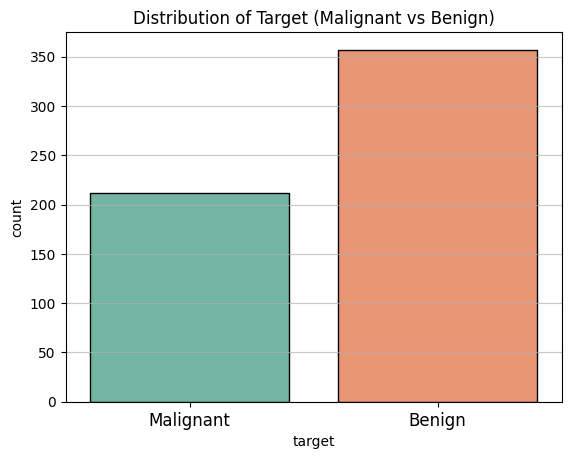

In [32]:
palette = sns.color_palette('Set2') 
sns.countplot(x='target', data = df, palette = palette, edgecolor = 'black') 
plt.title('Distribution of Target (Malignant vs Benign)', fontsize = 12) 
plt.xticks(ticks=[0, 1], labels=['Malignant', 'Benign'], fontsize = 12) 
plt.grid(axis='y', alpha = 0.7) 
plt.show()

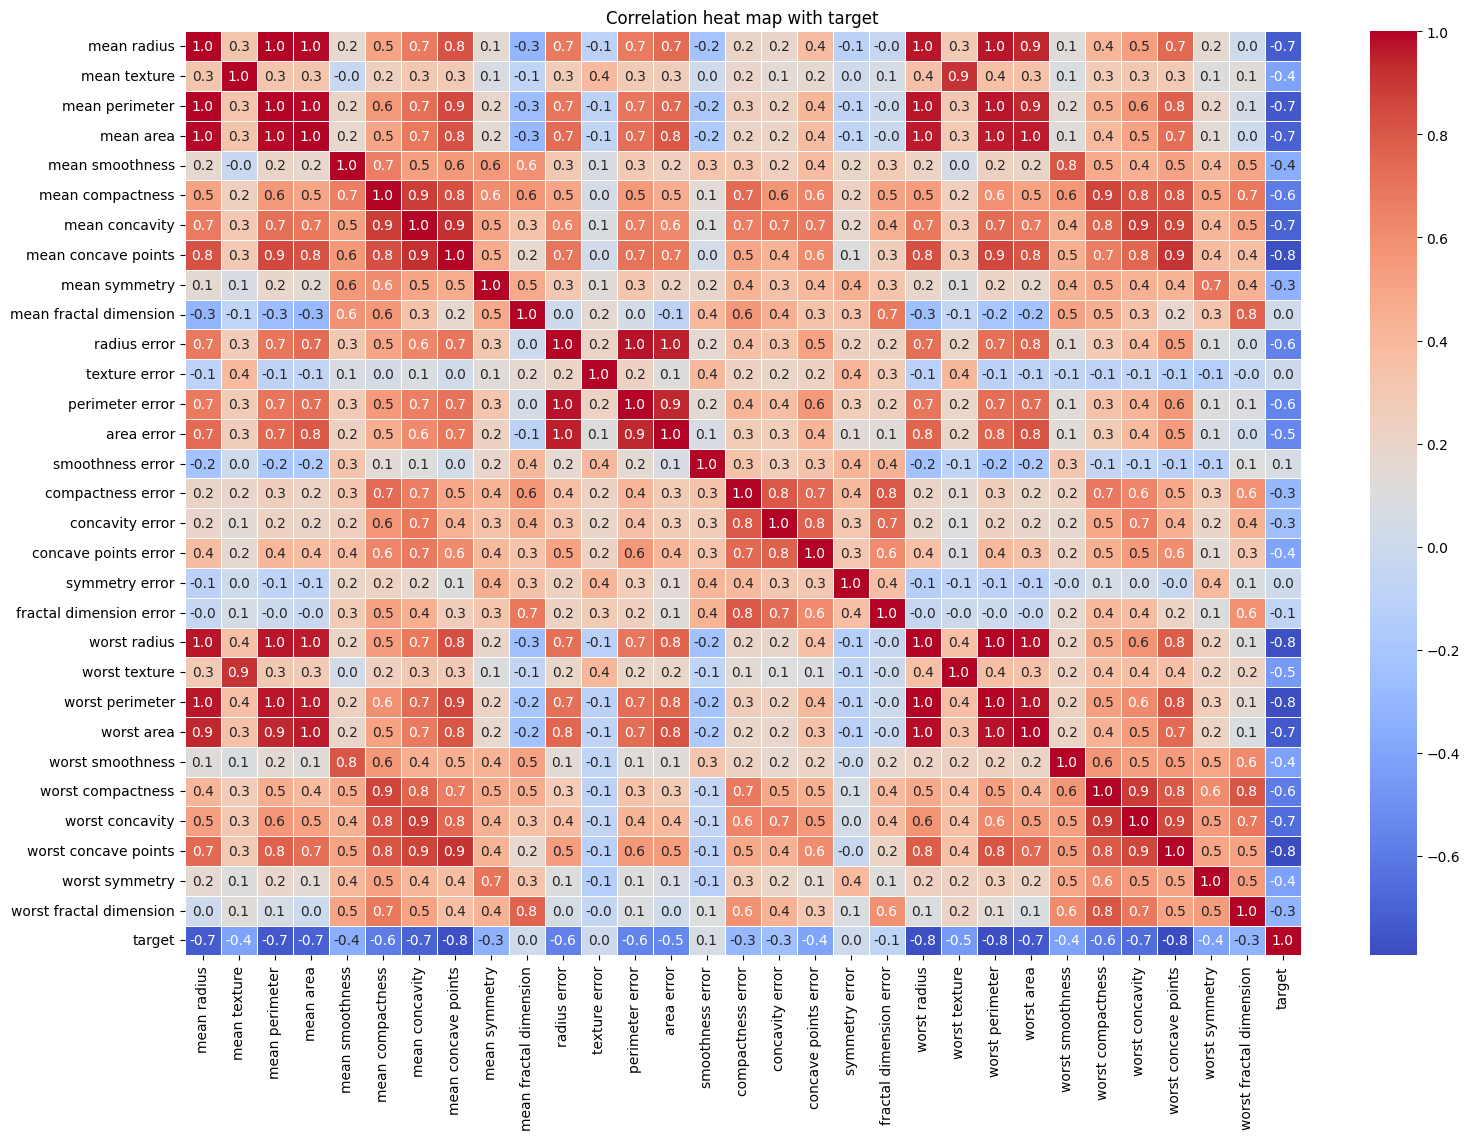

In [33]:
# Add the target variable to the dataframe for correlation claculation 
df_with_target = df.copy() 

corr_matrix_target = df_with_target.corr() 

# Plotting the ccorrelation_matrix
plt.figure(figsize=(18,12))
sns.heatmap(corr_matrix_target, annot= True, cmap='coolwarm', fmt='.1f', linewidths=0.4) 
plt.title('Correlation heat map with target')
plt.show()

In [34]:
# get correlation with the target 
correlation = corr_matrix_target['target'].drop('target').abs()
important_features = correlation.sort_values(ascending=False) 
worst_features = correlation.sort_values(ascending=True) 
top_features = important_features.head(10).index.tolist() 
worst_features = worst_features.head(10).index.tolist()
print(top_features)

['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter', 'worst area', 'mean radius', 'mean area', 'mean concavity', 'worst concavity']


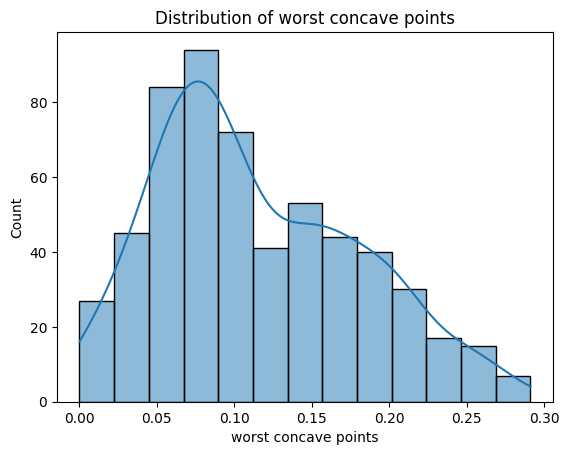

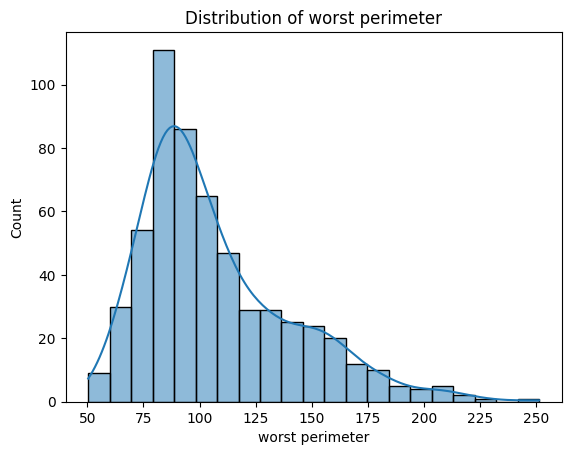

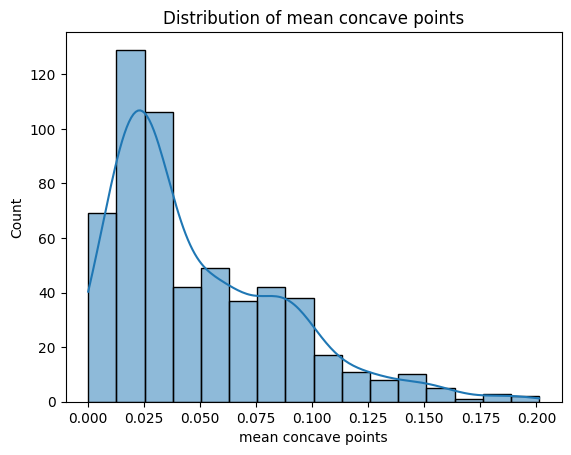

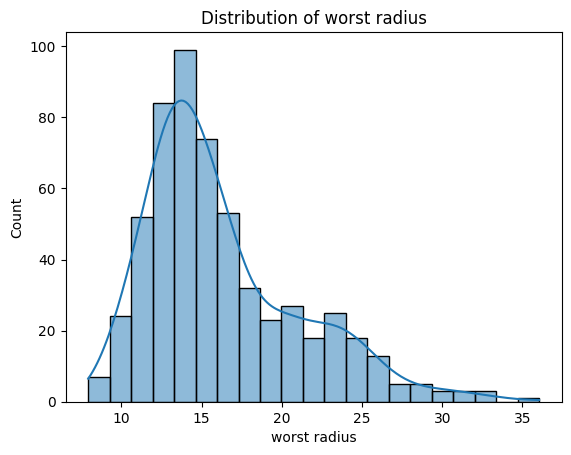

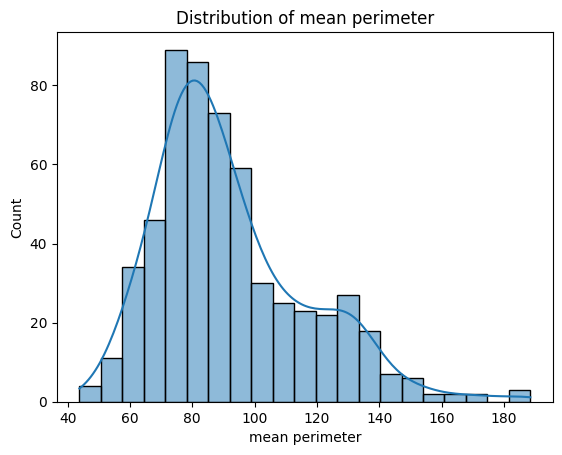

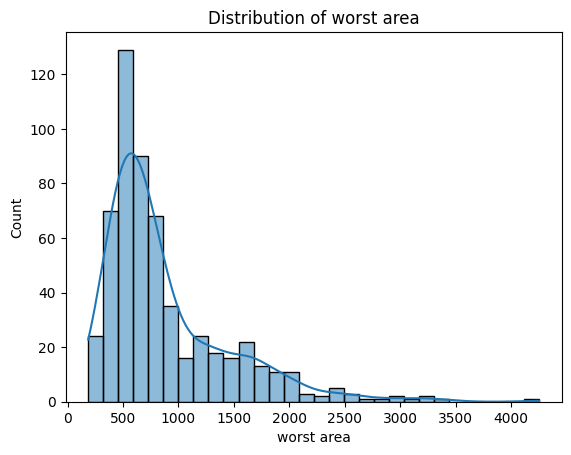

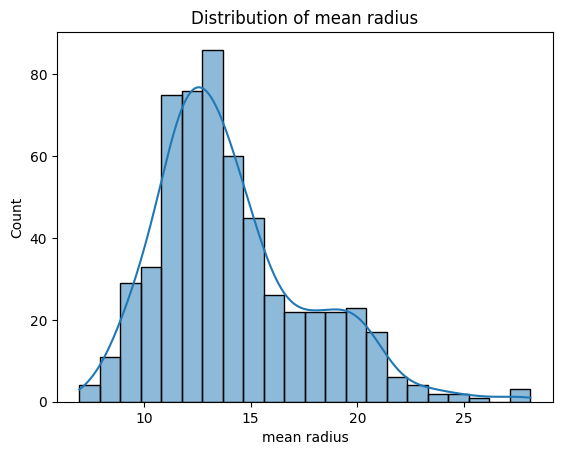

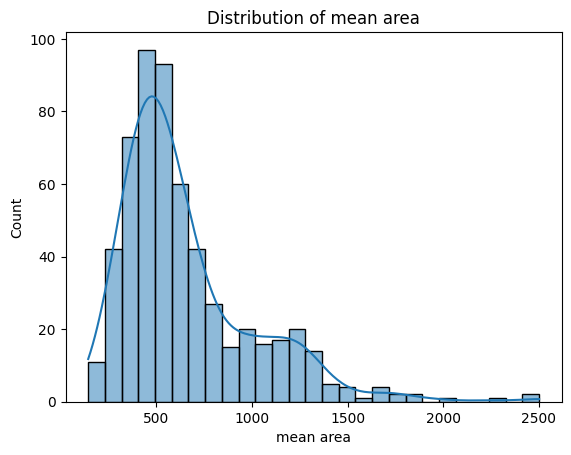

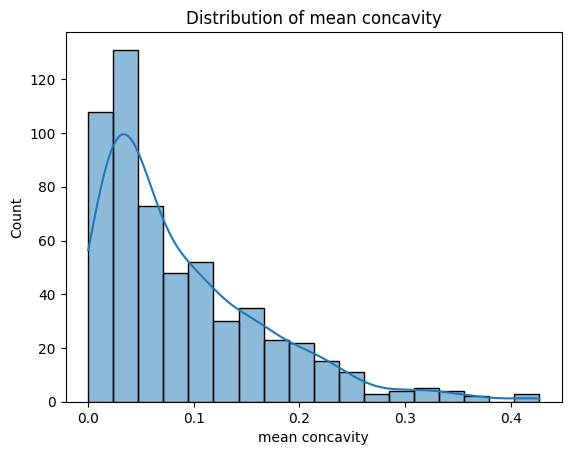

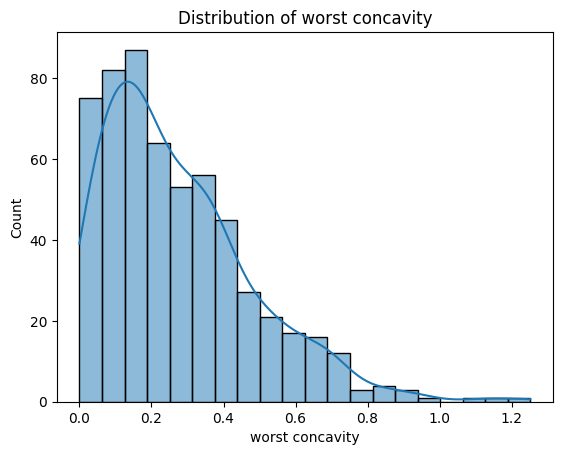

In [35]:
feature_to_plot = top_features
for feature in feature_to_plot:
    sns.histplot(df[feature], kde = True) 
    plt.title(f"Distribution of {feature}") 
    plt.show() 

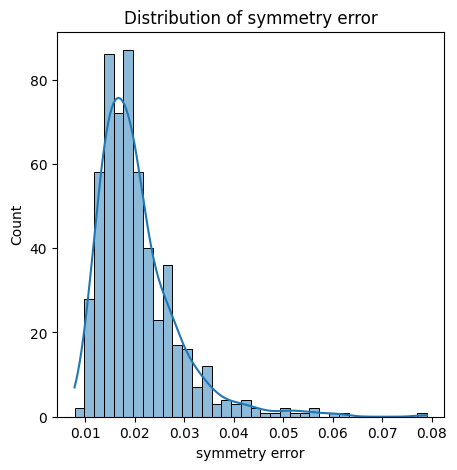

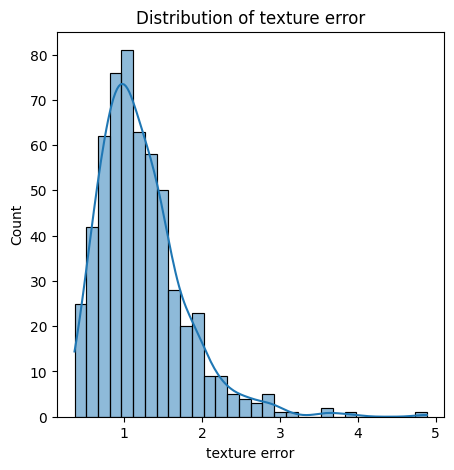

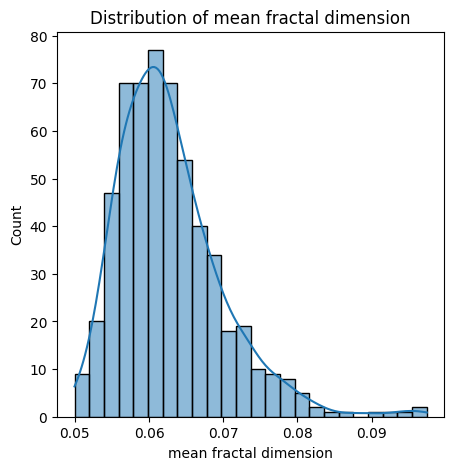

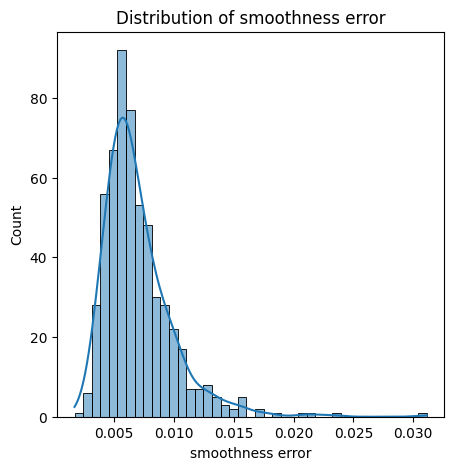

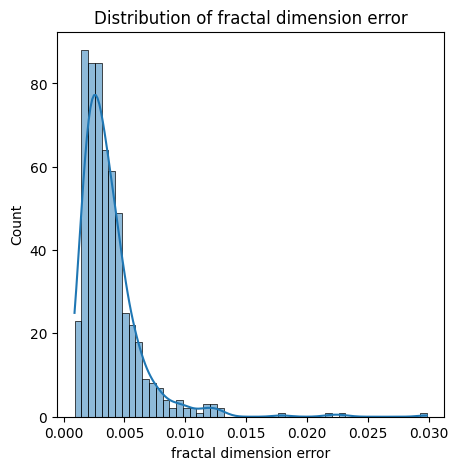

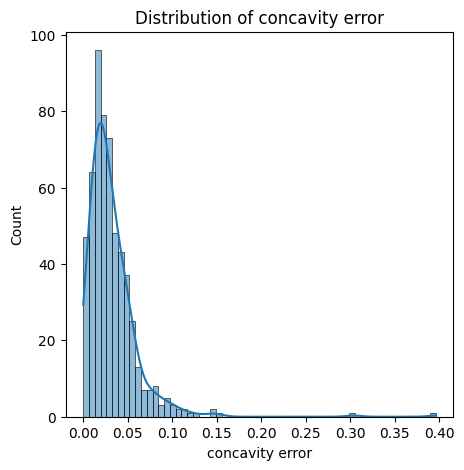

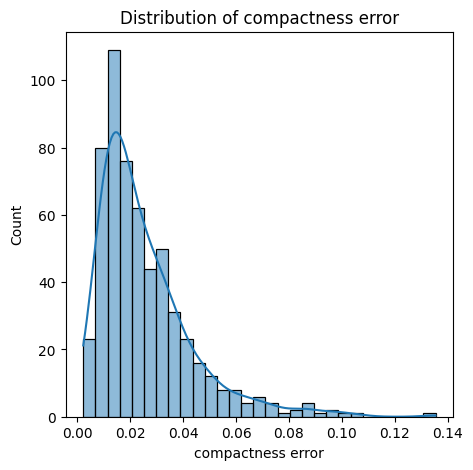

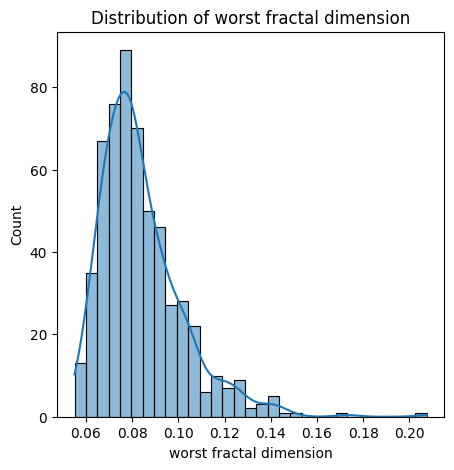

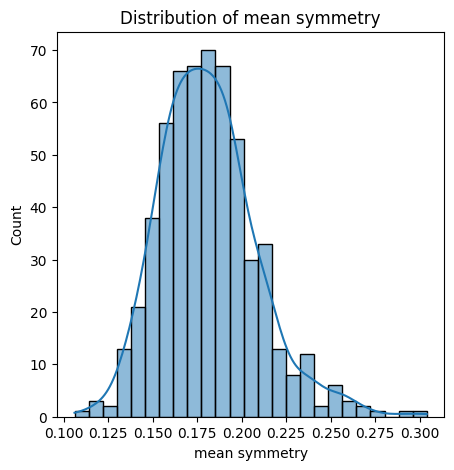

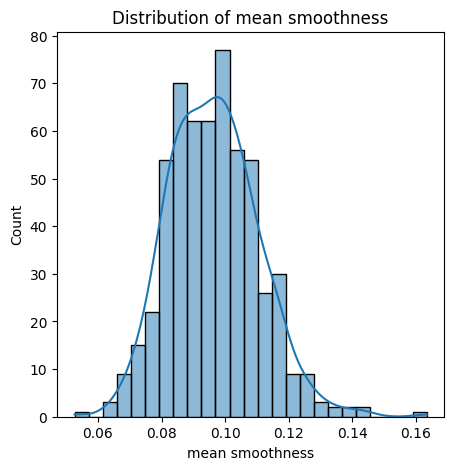

In [36]:
feature_to_plot = worst_features
for feature in feature_to_plot:
    plt.figure(figsize=(5, 5))
    sns.histplot(df[feature], kde = True) 
    plt.title(f"Distribution of {feature}") 
    plt.show()

In [37]:
top_features

['worst concave points',
 'worst perimeter',
 'mean concave points',
 'worst radius',
 'mean perimeter',
 'worst area',
 'mean radius',
 'mean area',
 'mean concavity',
 'worst concavity']

In [38]:
worst_features

['symmetry error',
 'texture error',
 'mean fractal dimension',
 'smoothness error',
 'fractal dimension error',
 'concavity error',
 'compactness error',
 'worst fractal dimension',
 'mean symmetry',
 'mean smoothness']

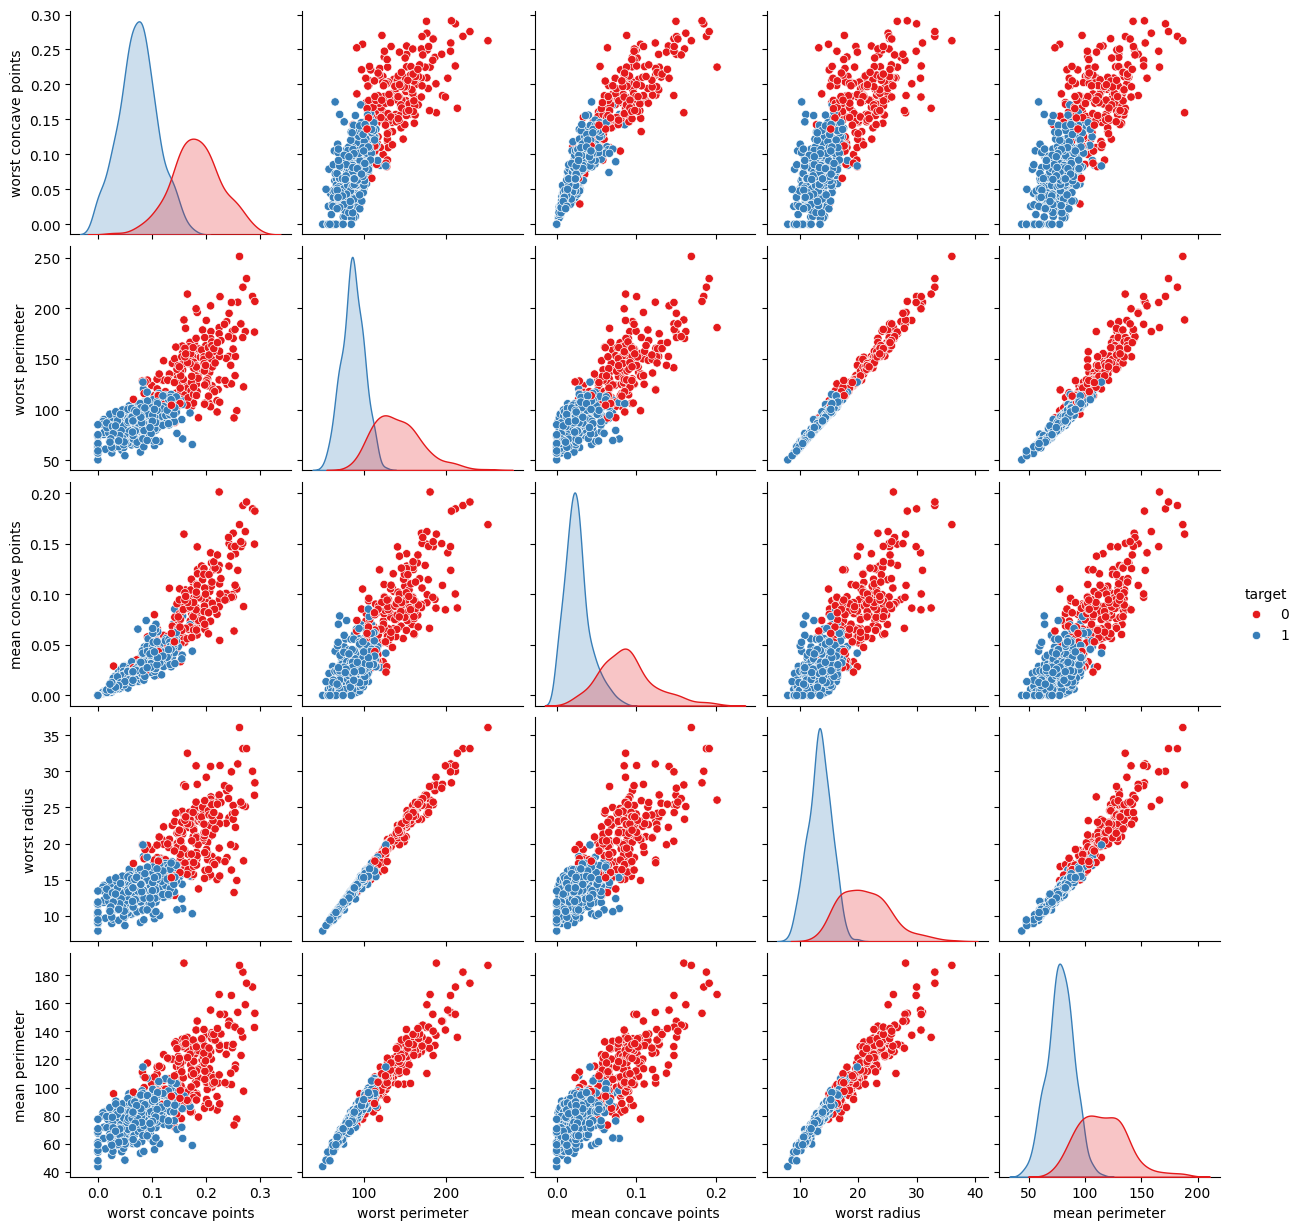

In [39]:
sns.pairplot(df, vars= top_features[:5], hue='target', palette='Set1')
plt.savefig("pairplot_best_features.png", dpi=300, bbox_inches='tight')
plt.show()

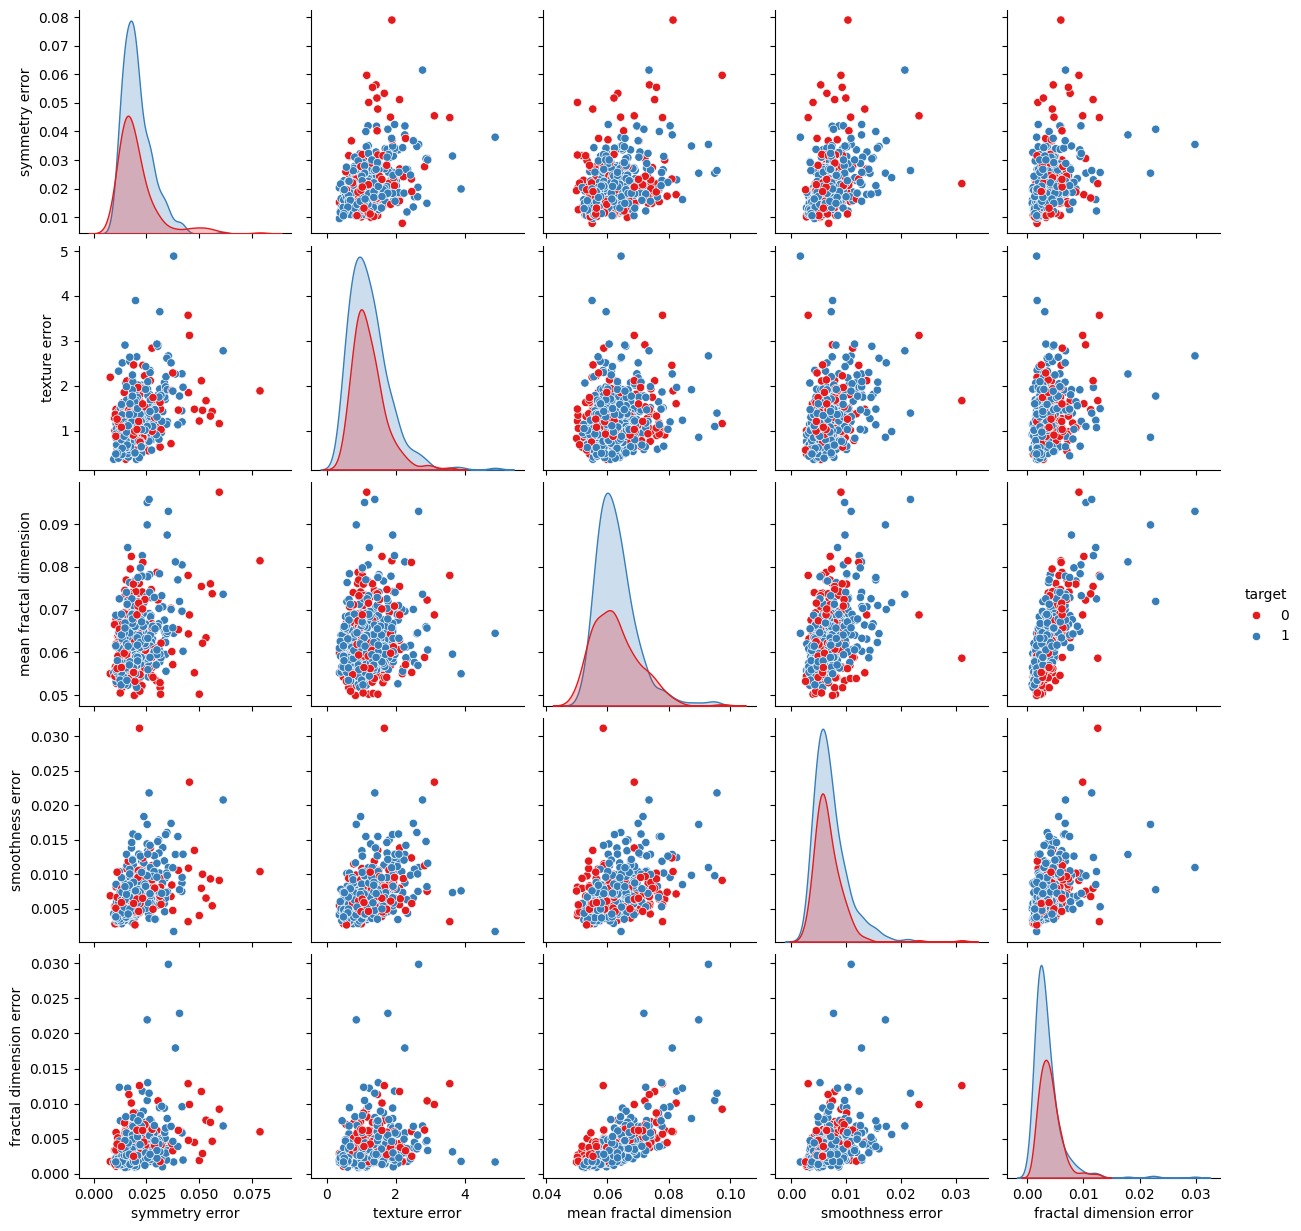

In [40]:
sns.pairplot(df, vars= worst_features[:5], hue='target', palette='Set1')
plt.savefig("pairplot_worst_features.png", dpi=300, bbox_inches='tight')
plt.show()

In [41]:
data = load_breast_cancer()
df = pd.DataFrame(data['data'], columns=data['feature_names'])
df['target'] = data['target']

use_top_features = True

if use_top_features:
    x = df[['mean area', 'worst concavity']].values
else:
    x = df.drop(columns='target').values

y = df['target'].values

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2) 
scaler = StandardScaler() 

x_train = scaler.fit_transform(x_train) 
x_test = scaler.transform(x_test) 

In [43]:
!pip install imageio

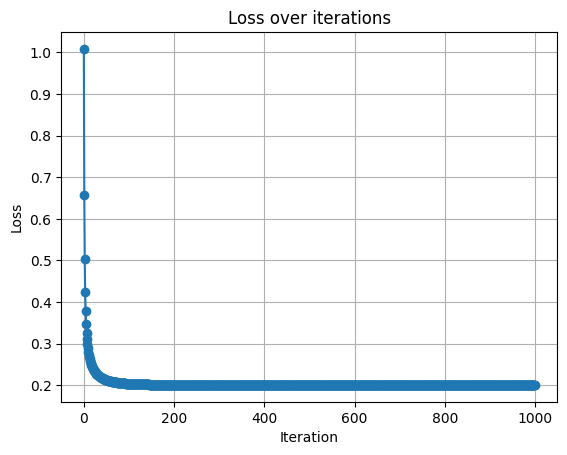

Accuracy: 92.98%


In [45]:
import imageio
from sklearn.metrics import accuracy_score

model = LogisticRegression(learning_rate= 0.02, max_iter= 1000, batch_size= 8) 
model.fit(x_train, y_train) 
model.plot_loss() 

y_pred = model.predict(x_test) 
accuracy = accuracy_score(y_test, y_pred) 
print(f'Accuracy: {accuracy*100:.2f}%') 

# create a gif from the saved frames 
image = [] 
for i in range(0, 1000, 10): 
    filename = f'frames/db_{i}.png' 
    image.append(imageio.imread(filename))

imageio.mimsave('db_spiral.gif', image, fps=5)

In [27]:
model.fit(x= x_train, y= y_train)

In [28]:
model.losses

[np.float64(1.0142644402732288),
 np.float64(0.6659870657638853),
 np.float64(0.5114913995499227),
 np.float64(0.4328803606551525),
 np.float64(0.3860909512303882),
 np.float64(0.3546444438780116),
 np.float64(0.33204302219967863),
 np.float64(0.31506443048910626),
 np.float64(0.3017050345882238),
 np.float64(0.2909592658788989),
 np.float64(0.2821009868964414),
 np.float64(0.2746331537758465),
 np.float64(0.26826260871589475),
 np.float64(0.26272757650198053),
 np.float64(0.25787479131940905),
 np.float64(0.253580335014257),
 np.float64(0.24976154319267532),
 np.float64(0.2463294222172193),
 np.float64(0.24321770227592684),
 np.float64(0.24039657222285118),
 np.float64(0.23782705802720783),
 np.float64(0.23545839893397907),
 np.float64(0.23329434288202663),
 np.float64(0.23127493570285107),
 np.float64(0.2294134192857253),
 np.float64(0.2276790415752809),
 np.float64(0.22605734737900418),
 np.float64(0.22454149950031185),
 np.float64(0.22312006224228098),
 np.float64(0.221791543746654